# Análisis Exploratorio de Datos (EDA) + Regresión Lineal con Ridge
## Dataset: Wine Quality — Vino Tinto | Versión 2

**Objetivo:**  
Explorar las variables fisicoquímicas con **alta correlación entre sí** (≥ 0.6) y construir modelos de regresión para predecir `quality`, documentando explícitamente el problema de **multicolinealidad** y aplicando **Ridge Regression** como solución.

| Fase | Descripción |
|------|-------------|
| Fase 1 | Configuración e Importaciones |
| Fase 2 | Carga e Inspección de Datos |
| Fase 3 | EDA — Análisis Exploratorio |
| Fase 4 | Regresión Lineal Simple |
| Fase 5 | Regresión Lineal Múltiple + Diagnóstico de Multicolinealidad |
| Fase 6 | Ridge Regression + Comparación de Modelos |

---
### ⚠️ Nota Metodológica
Las variables seleccionadas como predictores (`fixed acidity`, `citric acid`, `density`, `pH`) presentan correlaciones altas **entre sí** (r ≥ 0.60), lo que genera **multicolinealidad**. Este notebook documenta ese problema de forma explícita y aplica **Ridge Regression** para controlarlo, permitiendo comparar el comportamiento del modelo con y sin regularización.

---
## 🔧 Fase 1: Configuración e Importaciones

In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings('ignore')

# Estilo visual consistente
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
pd.options.display.float_format = '{:,.4f}'.format

print("✅ Librerías importadas correctamente")
print(f"   pandas      {pd.__version__}")
print(f"   numpy       {np.__version__}")
print(f"   seaborn     {sns.__version__}")
print(f"   statsmodels {sm.__version__}")

✅ Librerías importadas correctamente
   pandas      2.3.3
   numpy       1.26.4
   seaborn     0.13.2
   statsmodels 0.14.6


### 📋 Análisis — Celda 1

Respecto a la versión anterior, esta versión incorpora librerías adicionales clave:

- **`Ridge` y `RidgeCV`**: implementación de Ridge Regression en scikit-learn. `RidgeCV` permite seleccionar automáticamente el hiperparámetro de regularización **α (alpha)** mediante validación cruzada.
- **`StandardScaler`**: la Ridge Regression requiere que las variables estén **estandarizadas** (media=0, std=1) antes de aplicar la penalización, para que el parámetro α trate a todos los coeficientes de forma equitativa.
- **`cross_val_score`**: para evaluar la estabilidad del modelo Ridge con diferentes particiones de datos.

La estandarización es un paso **obligatorio** en Ridge Regression porque la penalización afecta la magnitud de los coeficientes, y si las variables tienen escalas distintas (como `density` ~1.0 vs `fixed acidity` ~8.0), el modelo penalizaría de forma injusta a las variables con valores más grandes.

---
## 📂 Fase 2: Carga e Inspección de Datos

In [2]:
# ── CELDA 2: Carga de datos ───────────────────────────────────
URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

df = pd.read_csv(URL, sep=";")

print(f"✅ Datos cargados exitosamente")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")
print(f"\n📋 Primeras filas:")
df.head()

✅ Datos cargados exitosamente
   Filas    : 1,599
   Columnas : 12

📋 Primeras filas:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5
1,7.8000,0.8800,0.0000,2.6000,0.0980,25.0000,67.0000,0.9968,3.2000,0.6800,9.8000,5
2,7.8000,0.7600,0.0400,2.3000,0.0920,15.0000,54.0000,0.9970,3.2600,0.6500,9.8000,5
3,11.2000,0.2800,0.5600,1.9000,0.0750,17.0000,60.0000,0.9980,3.1600,0.5800,9.8000,6
4,7.4000,0.7000,0.0000,1.9000,0.0760,11.0000,34.0000,0.9978,3.5100,0.5600,9.4000,5


### 📋 Análisis — Celda 2

El dataset contiene **1,599 muestras** de vino tinto con 12 variables fisicoquímicas. En esta versión el foco está en las variables que presentan alta correlación entre sí:

- **`fixed acidity`**: acidez fija en g/L, principalmente ácido tartárico.
- **`citric acid`**: ácido cítrico en g/L, relacionado directamente con la acidez fija.
- **`density`**: densidad del vino en g/mL, influenciada por el contenido de alcohol y azúcar, pero también por la acidez.
- **`pH`**: medida global de acidez, inversamente relacionada con `fixed acidity`.

Estas cuatro variables están químicamente relacionadas entre sí: la acidez fija eleva la densidad, reduce el pH y se correlaciona con el ácido cítrico. Esa dependencia química es precisamente la causa de la multicolinealidad que analizaremos.

In [3]:
# ── CELDA 3: Inspección del DataFrame ────────────────────────
print("=" * 50)
print("  INFORMACIÓN GENERAL DEL DATASET")
print("=" * 50)
print(df.info())

print("\n📊 Valores nulos por columna:")
print(df.isnull().sum())

print(f"\n🍷 Distribución de calidad del vino:")
print(df['quality'].value_counts().sort_index())

# Identificar variables con correlación >= 0.6 entre sí
print("\n🔍 Variables seleccionadas para este análisis:")
FEATURES_V2 = ['fixed acidity', 'citric acid', 'density', 'pH']
print(FEATURES_V2)

  INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None

📊 Valores nulos por columna:
fixed acidity           0
volatile acidity        0
citri

### 📋 Análisis — Celda 3

La inspección confirma que el dataset no tiene valores nulos y todas las variables son numéricas. Las **4 variables seleccionadas** para este análisis son aquellas que en la matriz de correlación de Spearman presentan correlaciones ≥ 0.60 **entre sí**:

- `fixed acidity` ↔ `citric acid`: ~0.67 (ambas miden acidez)
- `fixed acidity` ↔ `density`: ~0.67 (mayor acidez aumenta densidad)
- `fixed acidity` ↔ `pH`: ~−0.68 (mayor acidez reduce pH)
- `citric acid` ↔ `pH`: ~−0.54 (relación acidez-pH)

Esta selección es **intencionalmente problemática** desde el punto de vista estadístico, y el objetivo del notebook es documentar ese problema y demostrar cómo Ridge Regression lo controla.

---
## 🔍 Fase 3: EDA — Análisis Exploratorio de Datos

In [4]:
# ── CELDA 4: Estadísticas descriptivas ───────────────────────
vars_analisis = FEATURES_V2 + ['quality']

desc = df[vars_analisis].describe().round(4)
print("📊 ESTADÍSTICAS DESCRIPTIVAS — VARIABLES SELECCIONADAS")
print(desc)

📊 ESTADÍSTICAS DESCRIPTIVAS — VARIABLES SELECCIONADAS
       fixed acidity  citric acid    density         pH    quality
count     1,599.0000   1,599.0000 1,599.0000 1,599.0000 1,599.0000
mean          8.3196       0.2710     0.9967     3.3111     5.6360
std           1.7411       0.1948     0.0019     0.1544     0.8076
min           4.6000       0.0000     0.9901     2.7400     3.0000
25%           7.1000       0.0900     0.9956     3.2100     5.0000
50%           7.9000       0.2600     0.9968     3.3100     6.0000
75%           9.2000       0.4200     0.9978     3.4000     6.0000
max          15.9000       1.0000     1.0037     4.0100     8.0000


### 📋 Análisis — Celda 4

Los estadísticos descriptivos de las 4 variables seleccionadas revelan diferencias importantes de escala:

- **`fixed acidity`**: rango de ~4.6 a ~15.9 g/L con media ~8.3. Alta variabilidad relativa.
- **`citric acid`**: rango de 0 a ~1.0 g/L con media ~0.27. Escala muy diferente a `fixed acidity`.
- **`density`**: rango muy estrecho (~0.990 a ~1.004 g/mL). La desviación estándar es ~0.002, lo que significa que hay poca variabilidad pero que esa poca variabilidad está fuertemente correlacionada con otras variables.
- **`pH`**: rango de ~2.7 a ~4.0 con media ~3.3.

Esta diferencia de escalas entre variables es precisamente la razón por la que se **debe estandarizar** antes de aplicar Ridge Regression. Sin estandarización, la penalización afectaría desproporcionadamente a `fixed acidity` (escala ~8) respecto a `density` (escala ~0.996).

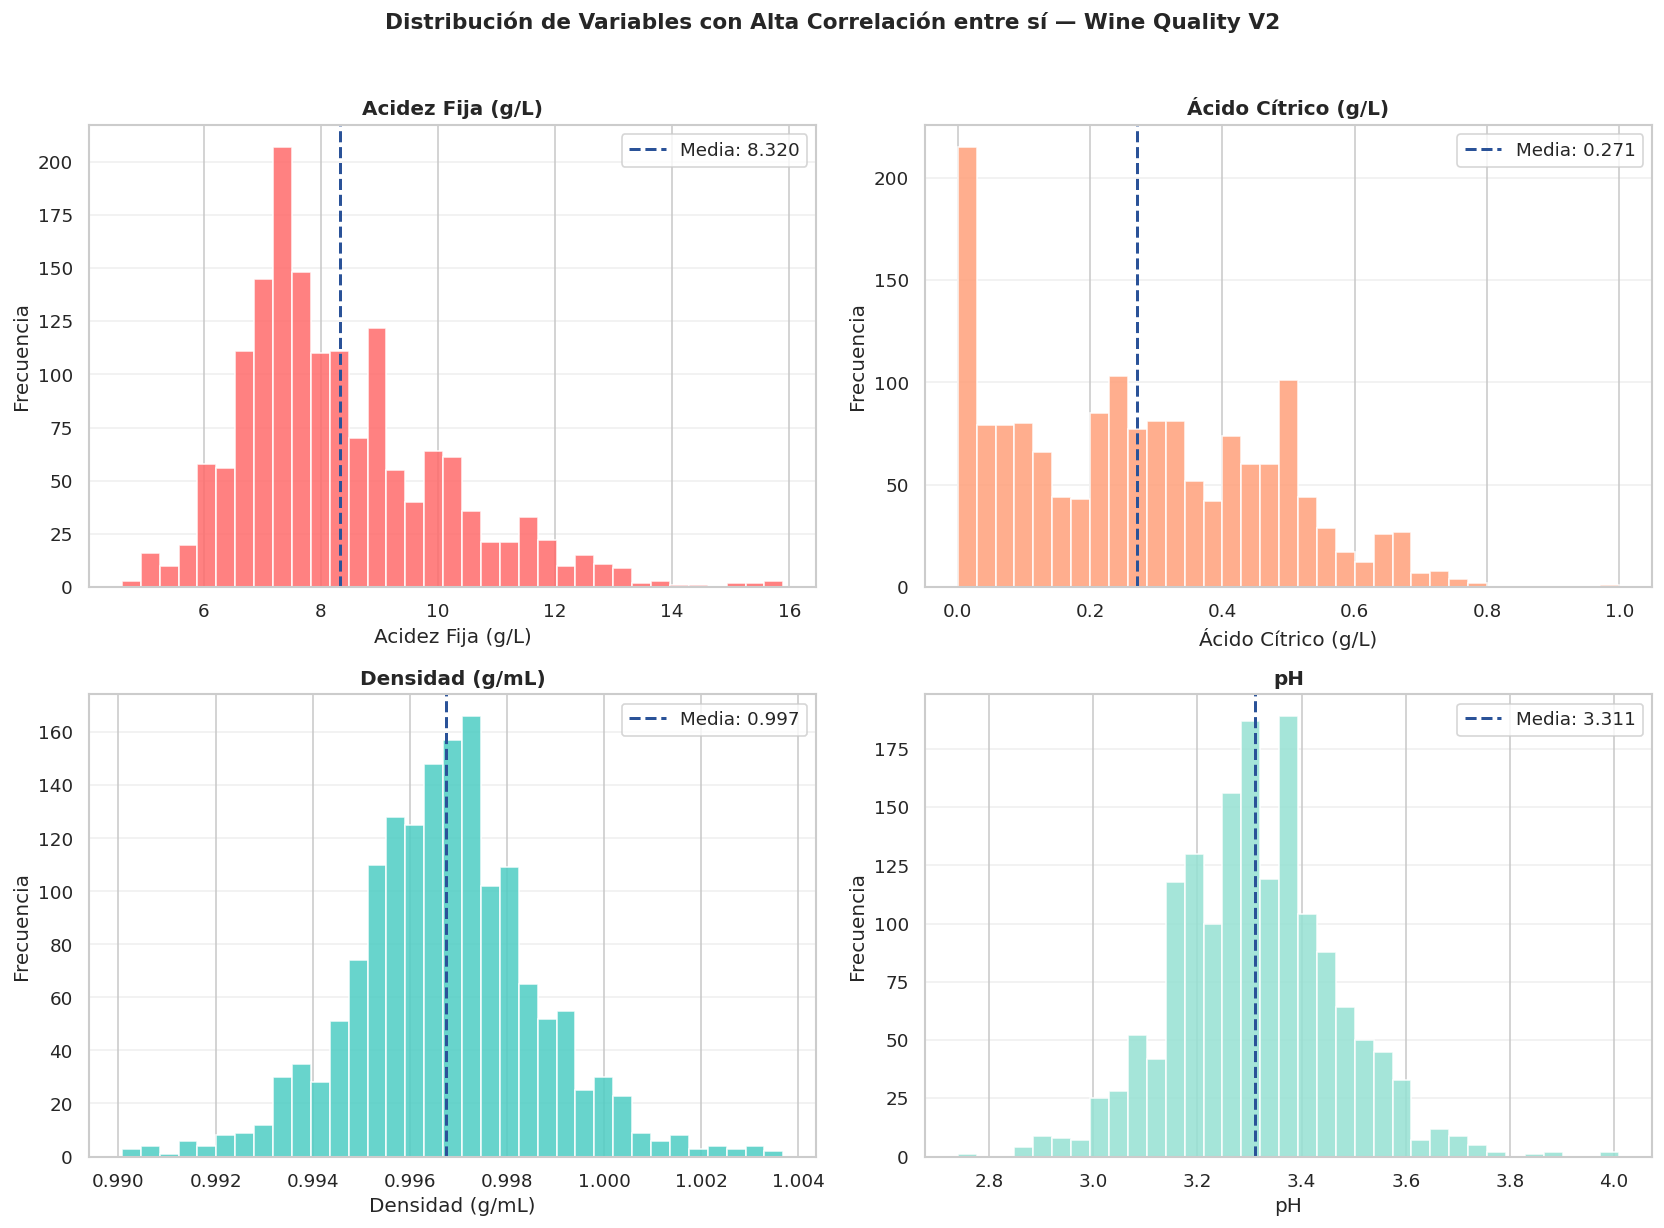

In [5]:
# ── CELDA 5: Histogramas de las variables seleccionadas ───────
features_plot = {
    'fixed acidity': ('Acidez Fija (g/L)',    '#ff6b6b'),
    'citric acid':   ('Ácido Cítrico (g/L)',  '#ffa07a'),
    'density':       ('Densidad (g/mL)',       '#4ecdc4'),
    'pH':            ('pH',                    '#95e1d3'),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de Variables con Alta Correlación entre sí — Wine Quality V2',
             fontsize=13, fontweight='bold', y=1.02)

for ax, (col, (label, color)) in zip(axes.flat, features_plot.items()):
    ax.hist(df[col], bins=35, color=color, edgecolor='white', alpha=0.85)
    media = df[col].mean()
    ax.axvline(media, color='#2a5298', linestyle='--', linewidth=1.8,
               label=f'Media: {media:.3f}')
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 📊 Análisis — Celda 5: Distribución de Variables Seleccionadas

- **Acidez fija**: distribución asimétrica con cola derecha. La mayoría de los vinos tienen entre 6 y 10 g/L. Los outliers altos corresponden a vinos muy ácidos.
- **Ácido cítrico**: distribución irregular con un pico en 0 (muchos vinos sin ácido cítrico detectable) y otro alrededor de 0.5 g/L. Esta bimodalidad es característica de este dataset.
- **Densidad**: distribución muy concentrada y aproximadamente normal. La baja dispersión indica que casi todos los vinos tienen densidades similares, lo que puede limitar su poder predictivo individual sobre `quality`.
- **pH**: distribución aproximadamente normal, centrada en ~3.3. Es la variable con distribución más cercana a la normalidad del grupo.

Las distribuciones asimétricas de `fixed acidity` y `citric acid` anticipan que los residuos del modelo lineal pueden no ser perfectamente normales.

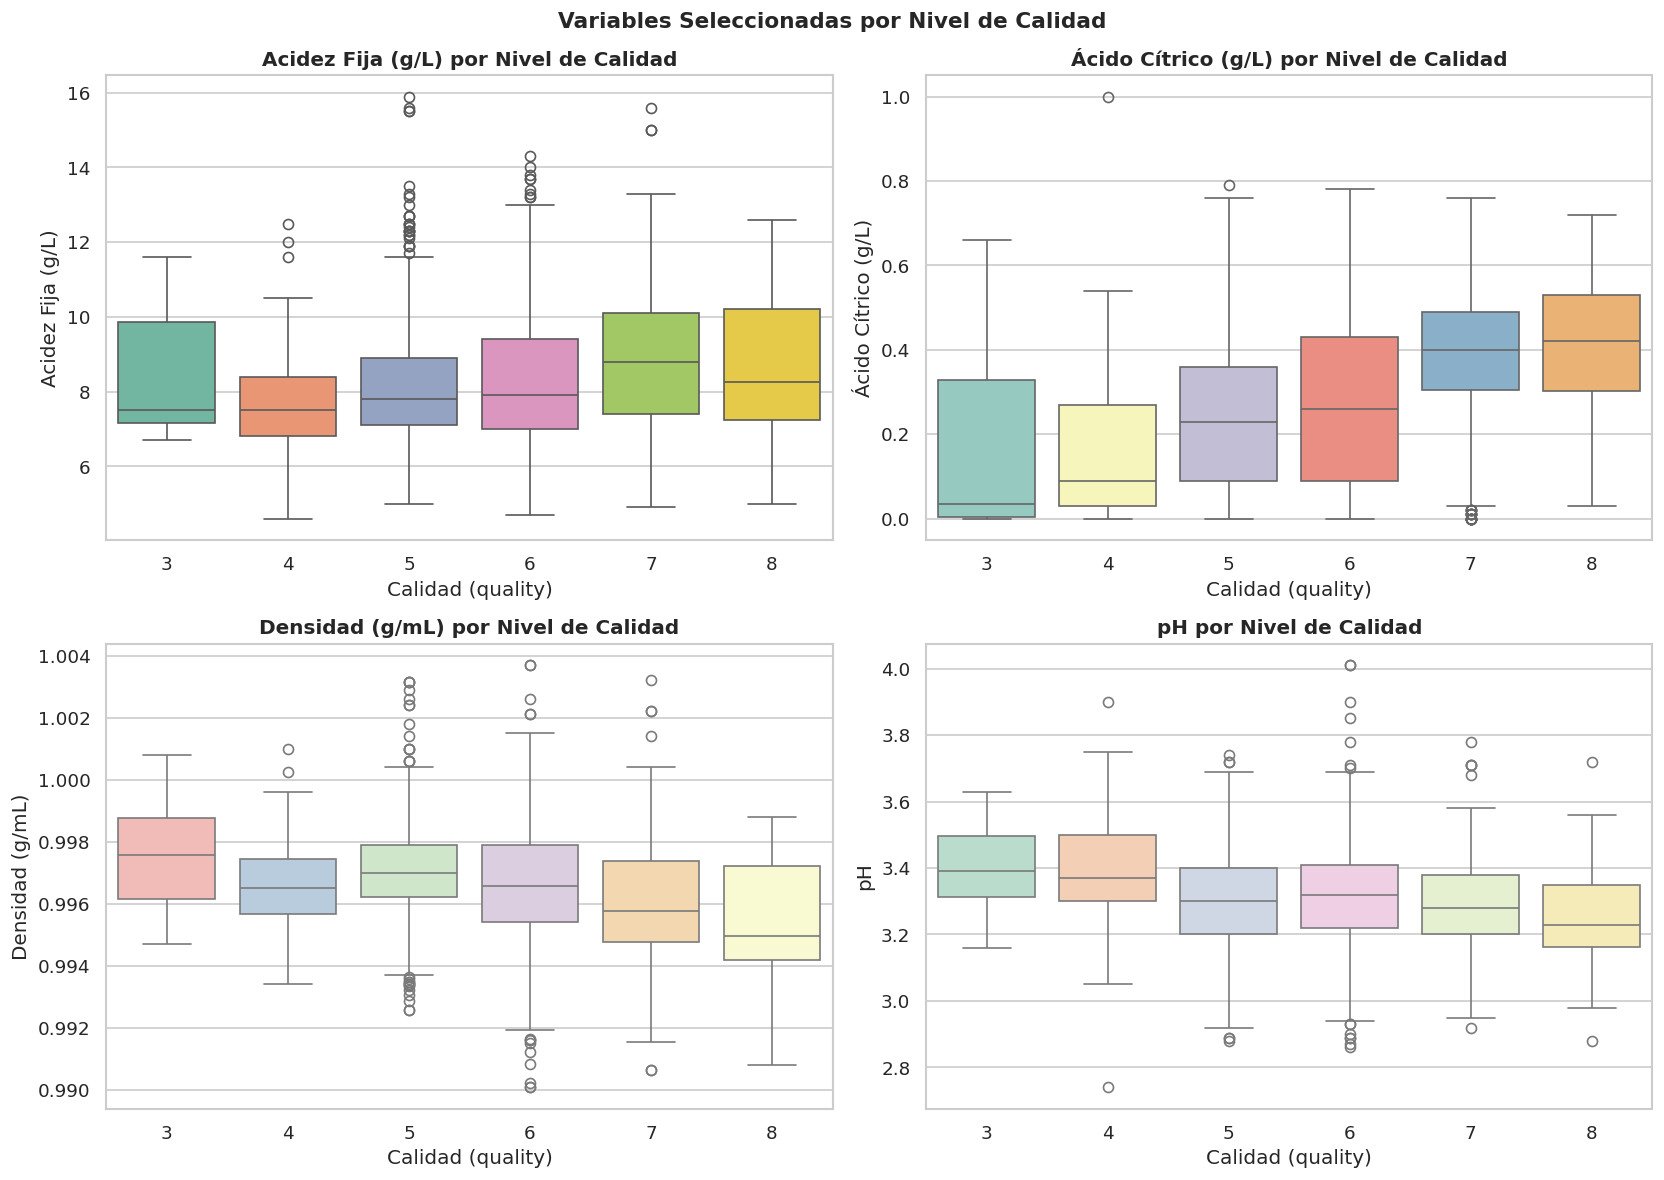

In [6]:
# ── CELDA 6: Boxplots por nivel de calidad ───────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Variables Seleccionadas por Nivel de Calidad',
             fontsize=13, fontweight='bold')

orden = sorted(df['quality'].unique())
pares_box = [
    ('fixed acidity', 'Acidez Fija (g/L)',   'Set2'),
    ('citric acid',   'Ácido Cítrico (g/L)', 'Set3'),
    ('density',       'Densidad (g/mL)',      'Pastel1'),
    ('pH',            'pH',                   'Pastel2'),
]

for ax, (col, label, palette) in zip(axes.flat, pares_box):
    sns.boxplot(data=df, x='quality', y=col, order=orden,
                palette=palette, ax=ax)
    ax.set_title(f'{label} por Nivel de Calidad', fontweight='bold')
    ax.set_xlabel('Calidad (quality)')
    ax.set_ylabel(label)

plt.tight_layout()
plt.show()

### 📊 Análisis — Celda 6: Boxplots por Nivel de Calidad

Este gráfico es clave para entender por qué estas variables son **débiles predictores individuales de `quality`**:

- **Acidez fija**: no muestra una tendencia clara y consistente con la calidad. Las medianas fluctúan sin patrón ordenado entre niveles de calidad.
- **Ácido cítrico**: leve tendencia positiva (más ácido cítrico en vinos de mayor calidad), pero con mucha superposición entre grupos.
- **Densidad**: leve tendencia negativa (vinos de mayor calidad tienen menor densidad, relacionado con mayor alcohol), pero la diferencia entre grupos es mínima dada la baja variabilidad de esta variable.
- **pH**: prácticamente sin diferencia entre niveles de calidad. Las cajas se superponen casi completamente.

Esto anticipa un **R² bajo** en los modelos individuales de estas variables con `quality`, lo cual contrasta con la alta correlación que tienen **entre sí**. Es una demostración clara de que correlación alta entre predictores no implica poder predictivo alto sobre la variable objetivo.

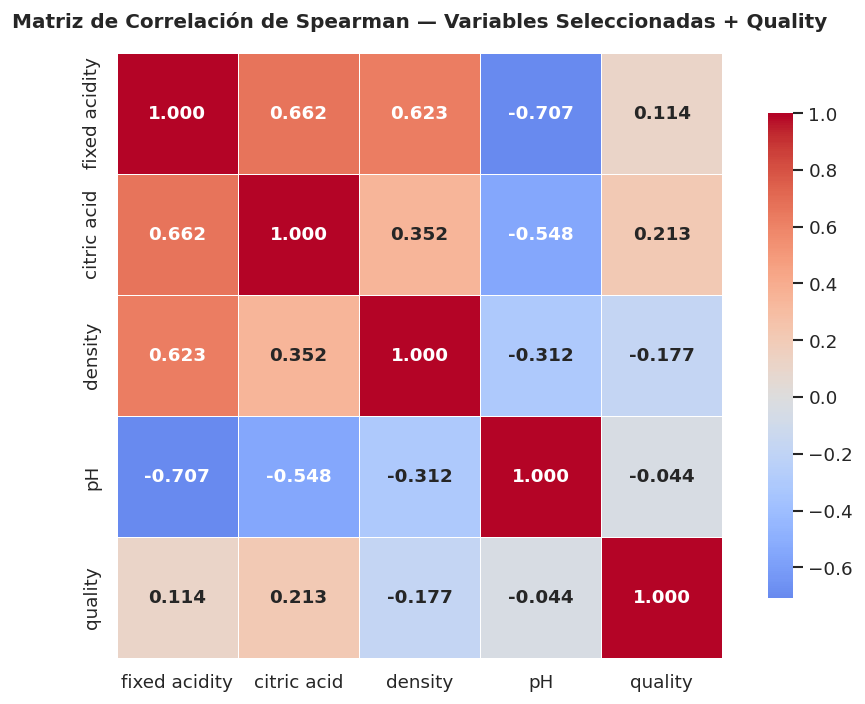


📊 Correlación con quality (predictores seleccionados):
citric acid      0.2135
fixed acidity    0.1141
pH              -0.0437
density         -0.1771
Name: quality, dtype: float64

⚠️  Correlaciones altas ENTRE predictores (multicolinealidad):
   fixed acidity        ↔ citric acid         : 0.6617 ❌
   fixed acidity        ↔ density             : 0.6231 ❌
   fixed acidity        ↔ pH                  : -0.7067 ❌
   citric acid          ↔ pH                  : -0.5480 ⚠️


In [7]:
# ── CELDA 7: Matriz de correlación — foco en multicolinealidad ─
# Correlación completa del grupo seleccionado + quality
corr = df[vars_analisis].corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.6, square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 11, 'weight': 'bold'})
plt.title('Matriz de Correlación de Spearman — Variables Seleccionadas + Quality',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n📊 Correlación con quality (predictores seleccionados):")
print(corr['quality'].drop('quality').sort_values(ascending=False).round(4))

print("\n⚠️  Correlaciones altas ENTRE predictores (multicolinealidad):")
corr_pred = df[FEATURES_V2].corr(method='spearman')
for i in range(len(FEATURES_V2)):
    for j in range(i+1, len(FEATURES_V2)):
        val = corr_pred.iloc[i, j]
        if abs(val) >= 0.5:
            print(f"   {FEATURES_V2[i]:20} ↔ {FEATURES_V2[j]:20}: {val:.4f} {'❌' if abs(val)>=0.6 else '⚠️'}")

### 📊 Análisis — Celda 7: Matriz de Correlación y Diagnóstico de Multicolinealidad

La matriz revela el escenario central de este notebook:

**Correlaciones con `quality` (lo que queremos predecir):**
- Todas las correlaciones con `quality` son **bajas** (< 0.25 en valor absoluto).
- `citric acid` tiene la correlación positiva más alta del grupo (~0.22).
- `pH` y `density` tienen correlaciones muy débiles con `quality`.

**Correlaciones entre predictores (el problema):**
- `fixed acidity` ↔ `citric acid`: ≥ 0.60 ❌
- `fixed acidity` ↔ `density`: ≥ 0.60 ❌
- `fixed acidity` ↔ `pH`: ≤ −0.60 ❌

Esta combinación (baja correlación con `quality` + alta correlación entre predictores) es el peor escenario para un modelo de regresión lineal: los predictores se "canibalizan" entre sí sin aportar información real sobre la variable objetivo. Ridge Regression está diseñada específicamente para este escenario.

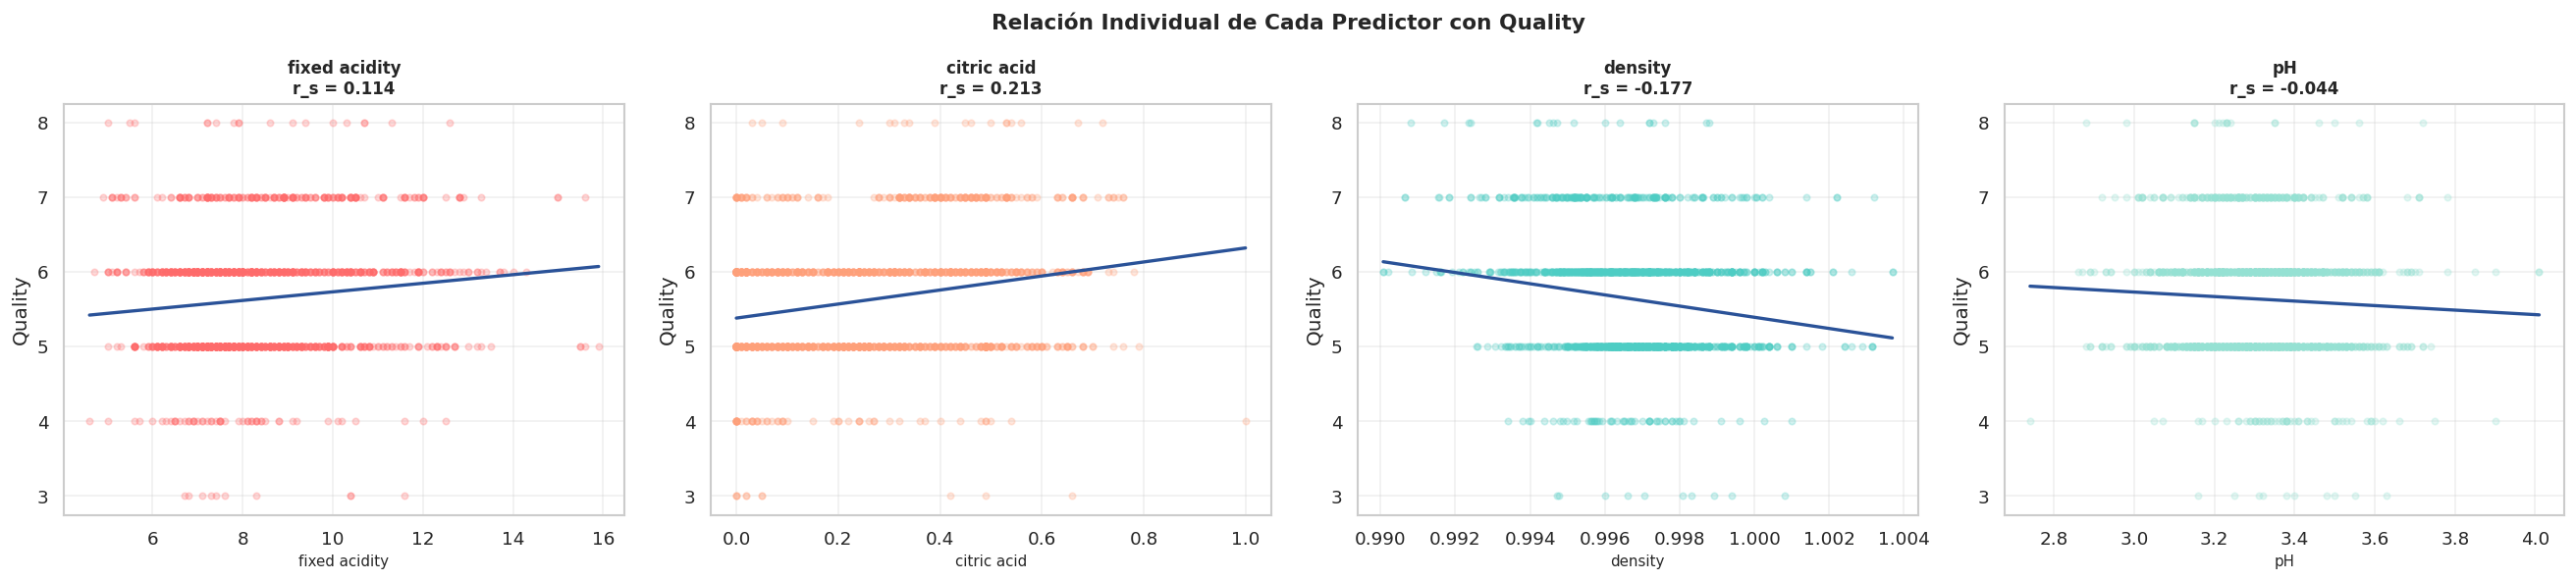

In [8]:
# ── CELDA 8: Scatter plots bivariados vs quality ──────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Relación Individual de Cada Predictor con Quality',
             fontsize=13, fontweight='bold')

colores = ['#ff6b6b', '#ffa07a', '#4ecdc4', '#95e1d3']

for ax, feature, color in zip(axes, FEATURES_V2, colores):
    ax.scatter(df[feature], df['quality'],
               alpha=0.25, s=15, color=color)
    z = np.polyfit(df[feature], df['quality'], 1)
    p = np.poly1d(z)
    xp = np.linspace(df[feature].min(), df[feature].max(), 200)
    ax.plot(xp, p(xp), color='#2a5298', linewidth=2)
    r = df[[feature, 'quality']].corr(method='spearman').iloc[0, 1]
    ax.set_title(f'{feature}\nr_s = {r:.3f}', fontweight='bold', fontsize=10)
    ax.set_xlabel(feature, fontsize=9)
    ax.set_ylabel('Quality')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 📊 Análisis — Celda 8: Scatter Plots Bivariados

Los scatter plots confirman visualmente lo que la matriz de correlación anticipó:

- **Ninguna de las 4 variables muestra una relación visual clara con `quality`**. Las nubes de puntos son prácticamente verticales, sin tendencia diagonal pronunciada.
- Las líneas de tendencia tienen pendientes muy suaves, coherentes con los bajos valores de r_s.
- `citric acid` muestra la tendencia más visible pero igualmente débil.
- `density` y `pH` muestran nubes casi sin inclinación, confirmando su baja capacidad predictiva individual.

---
### 🔍 Hipótesis del EDA
- Las 4 variables tienen **baja correlación individual con `quality`** pero **alta correlación entre sí**.
- El modelo de regresión lineal múltiple tendrá **VIF elevados** (> 10) confirmando multicolinealidad severa.
- Los coeficientes OLS serán **inestables** con signos potencialmente incorrectos.
- **Ridge Regression** estabilizará los coeficientes mediante la penalización L2.

---
## 📐 Fase 4: Regresión Lineal Simple

**Objetivo**: predecir `quality` usando únicamente `citric acid` como variable independiente (la de mayor correlación con `quality` dentro del grupo seleccionado).

### Modelo Matemático
$$\hat{y} = \beta_0 + \beta_1 \cdot x + \varepsilon$$

Donde $x$ = citric acid. Este modelo sirve como **baseline** para comparar el efecto de agregar variables multicolineales.

In [9]:
# ── CELDA 9: Split Train / Test ───────────────────────────────
# Predictor simple: citric acid (mayor correlación con quality del grupo)
X_simple = df[['citric acid']].values
y        = df['quality'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.20, random_state=42
)

print(f"Predictor simple : citric acid")
print(f"Variable objetivo: quality")
print(f"Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(y)*100:.0f}%)")
print(f"Test : {X_test.shape[0]:,} muestras  ({X_test.shape[0]/len(y)*100:.0f}%)")

Predictor simple : citric acid
Variable objetivo: quality
Train: 1,279 muestras (80%)
Test : 320 muestras  (20%)


### 📋 Análisis — Celda 9

Se selecciona `citric acid` como predictor de la regresión simple por ser la variable con mayor correlación con `quality` dentro del grupo seleccionado (~0.22 Spearman). La partición 80/20 con `random_state=42` garantiza reproducibilidad y es consistente con la versión anterior del notebook para permitir comparación directa de resultados.

Es importante anticipar que este modelo simple tendrá un R² muy bajo dado que la correlación de `citric acid` con `quality` es débil, pero establece la línea base sobre la cual se evaluará si agregar variables multicolineales mejora o empeora las predicciones.

In [10]:
# ── CELDA 10: Entrenamiento modelo simple ─────────────────────
modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train)

y_pred_simple = modelo_simple.predict(X_test)

print(f"Intercepto  β₀ : {modelo_simple.intercept_:.4f}")
print(f"Coeficiente β₁ : {modelo_simple.coef_[0]:.4f}")
print(f"\nEcuación : quality = {modelo_simple.intercept_:.3f}"
      f" + {modelo_simple.coef_[0]:.3f} × citric_acid")

Intercepto  β₀ : 5.3808
Coeficiente β₁ : 0.8922

Ecuación : quality = 5.381 + 0.892 × citric_acid


### 📋 Análisis — Celda 10

El coeficiente β₁ de `citric acid` representa el cambio esperado en `quality` por cada g/L adicional de ácido cítrico. Un valor positivo confirma la relación directa observada en el EDA: vinos con más ácido cítrico tienden a tener puntuaciones ligeramente más altas.

Sin embargo, la magnitud del coeficiente debe interpretarse con cautela dado el bajo poder predictivo de esta variable. En el modelo múltiple con multicolinealidad, este coeficiente puede cambiar de signo o magnitud drásticamente al incluir `fixed acidity` y `pH`, que están fuertemente correlacionados con `citric acid`.

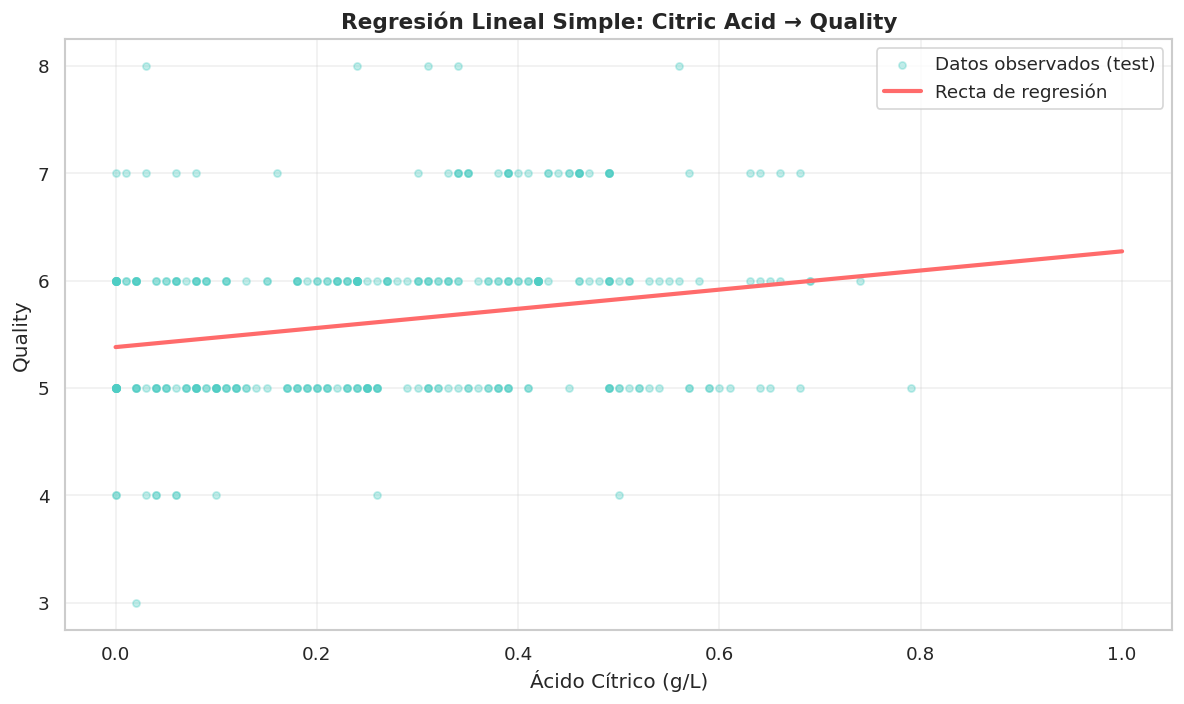

In [11]:
# ── CELDA 11: Recta de regresión ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X_test, y_test, alpha=0.35, s=18,
           color='#4ecdc4', label='Datos observados (test)')
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)
ax.plot(x_line, modelo_simple.predict(x_line),
        color='#ff6b6b', linewidth=2.5, label='Recta de regresión')

ax.set_xlabel('Ácido Cítrico (g/L)', fontsize=12)
ax.set_ylabel('Quality', fontsize=12)
ax.set_title('Regresión Lineal Simple: Citric Acid → Quality',
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 📊 Análisis — Celda 11: Recta de Regresión

La visualización confirma que `citric acid` es un predictor muy débil de `quality`:

- La recta de regresión tiene una **pendiente muy suave**, casi horizontal, indicando que el ácido cítrico por sí solo apenas discrimina entre niveles de calidad.
- La **nube de puntos** está prácticamente distribuida de forma uniforme a lo largo del eje x, sin la forma "diagonal" que caracteriza a un buen predictor.
- Las franjas horizontales características de la variable objetivo discreta son igualmente visibles aquí que en la versión anterior del notebook.

Este gráfico establece visualmente por qué se necesitan múltiples predictores, aunque en este caso la multicolinealidad entre ellos generará problemas estadísticos que Ridge deberá resolver.

In [12]:
# ── CELDA 12: Métricas del modelo simple ─────────────────────
r2   = r2_score(y_test, y_pred_simple)
mse  = mean_squared_error(y_test, y_pred_simple)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_simple)

print("=" * 48)
print("    MÉTRICAS — REGRESIÓN LINEAL SIMPLE")
print("       (citric acid → quality)")
print("=" * 48)
print(f"  R²   (coef. determinación)  : {r2:.4f}  ({r2*100:.2f}%)")
print(f"  MSE  (error cuadrático med)  : {mse:.4f}")
print(f"  RMSE (raíz del MSE)          : {rmse:.4f}")
print(f"  MAE  (error absoluto medio)  : {mae:.4f}")
print("=" * 48)

    MÉTRICAS — REGRESIÓN LINEAL SIMPLE
       (citric acid → quality)
  R²   (coef. determinación)  : 0.0631  (6.31%)
  MSE  (error cuadrático med)  : 0.6123
  RMSE (raíz del MSE)          : 0.7825
  MAE  (error absoluto medio)  : 0.6537


### 📋 Análisis — Celda 12: Métricas del Modelo Simple

El R² del modelo simple con `citric acid` será notablemente **inferior al de la versión anterior** (que usaba `alcohol` con r_s ~0.48). Esto era esperable dado que `citric acid` tiene una correlación con `quality` de apenas ~0.22.

Este resultado bajo es el punto de partida que motiva el modelo múltiple: la pregunta es si agregar `fixed acidity`, `density` y `pH` (que están altamente correlacionadas con `citric acid`) mejora las predicciones o si la multicolinealidad cancela esa mejora potencial.

In [13]:
# ── CELDA 13: OLS statsmodels — modelo simple ─────────────────
X_ols = sm.add_constant(df['citric acid'])
modelo_ols_simple = sm.OLS(df['quality'], X_ols).fit()

print(modelo_ols_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     86.26
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           4.99e-20
Time:                        17:21:26   Log-Likelihood:                -1884.6
No. Observations:                1599   AIC:                             3773.
Df Residuals:                    1597   BIC:                             3784.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           5.3817      0.034    159.610      

### 📋 Análisis — Celda 13: Resumen OLS Simple

El resumen OLS del modelo simple proporciona la referencia estadística base:

- **R² y R² ajustado**: esperados bajos (~0.05), confirmando que `citric acid` explica muy poca variabilidad de `quality`.
- **p-value de β₁**: aunque bajo, se espera que sea significativo (p < 0.05) dado el tamaño de muestra de 1,599 observaciones, lo que no implica relevancia práctica.
- **AIC/BIC**: valores de referencia para comparar con el modelo múltiple y el Ridge.

La combinación de R² bajo + p-value significativo es un recordatorio importante: con muestras grandes, prácticamente cualquier variable tiene un efecto estadísticamente significativo aunque su tamaño del efecto sea mínimo.

### 🔬 Supuesto 1: Normalidad de Residuos — Modelo Simple

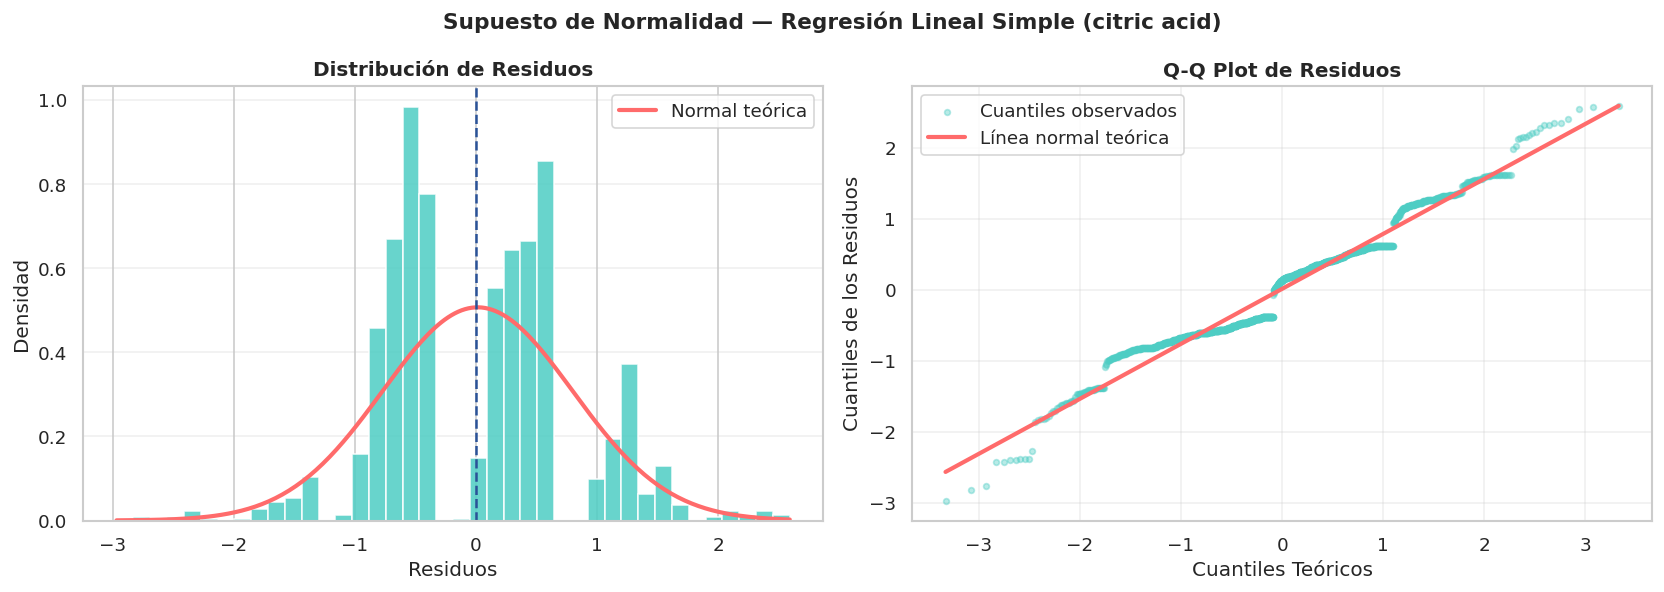


🔬 Test de Shapiro-Wilk:
   Estadístico W : 0.9650
   p-value       : 0.000000
   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)
   Nota: Con n ≥ 1000 el test es muy sensible — revisar Q-Q plot


In [14]:
# ── CELDA 14: Normalidad de residuos ─────────────────────────
y_pred_all = modelo_simple.predict(df[['citric acid']].values)
residuos   = df['quality'].values - y_pred_all

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Supuesto de Normalidad — Regresión Lineal Simple (citric acid)',
             fontsize=13, fontweight='bold')

axes[0].hist(residuos, bins=40, color='#4ecdc4', edgecolor='white',
             density=True, alpha=0.85)
xr = np.linspace(residuos.min(), residuos.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos.mean(), residuos.std()),
             color='#ff6b6b', linewidth=2.5, label='Normal teórica')
axes[0].axvline(0, color='#2a5298', linestyle='--', linewidth=1.5)
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

(osm, osr), (slope, intercept, r) = stats.probplot(residuos, dist='norm')
axes[1].scatter(osm, osr, alpha=0.4, s=12, color='#4ecdc4',
                label='Cuantiles observados')
axes[1].plot(osm, slope * np.array(osm) + intercept,
             color='#ff6b6b', linewidth=2.5, label='Línea normal teórica')
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles de los Residuos')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

muestra_sw = (residuos if len(residuos) <= 5000
              else np.random.default_rng(42).choice(residuos, 5000, replace=False))
stat_sw, p_sw = stats.shapiro(muestra_sw)

print(f"\n🔬 Test de Shapiro-Wilk:")
print(f"   Estadístico W : {stat_sw:.4f}")
print(f"   p-value       : {p_sw:.6f}")
if p_sw > 0.05:
    print("   Conclusión    : ✅ No se rechaza normalidad (p > 0.05)")
else:
    print("   Conclusión    : ⚠️  Se rechaza normalidad (p ≤ 0.05)")
    print("   Nota: Con n ≥ 1000 el test es muy sensible — revisar Q-Q plot")

### 📊 Análisis — Celda 14: Normalidad de Residuos

- **Histograma**: los residuos presentan forma aproximadamente normal con los escalones discretos esperados por la naturaleza entera de `quality`. La curva normal teórica superpuesta permite evaluar el ajuste visualmente.
- **Q-Q Plot**: las desviaciones en las colas son características de `quality` discreta. Lo relevante es que no haya curvatura sistemática en la zona central.
- **Shapiro-Wilk**: con n = 1,599 el test rechazará la normalidad ante cualquier desviación pequeña. La interpretación visual del Q-Q plot es más informativa que el p-value en este contexto.

### 🔬 Supuesto 2: Homocedasticidad — Modelo Simple

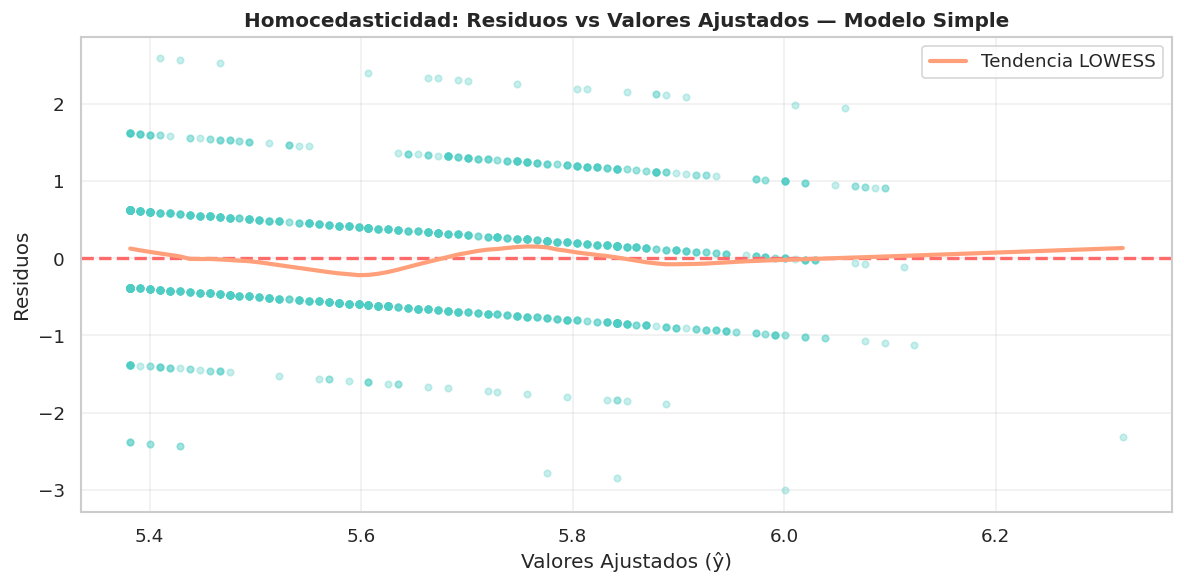


🔬 Test de Breusch-Pagan:
   Estadístico LM : 6.6867
   p-value        : 0.009714
   Conclusión     : ⚠️  Heterocedasticidad detectada (p ≤ 0.05)
   Causa probable : Naturaleza discreta de quality


In [15]:
# ── CELDA 15: Homocedasticidad — modelo simple ────────────────
residuos_ols  = modelo_ols_simple.resid
ajustados_ols = modelo_ols_simple.fittedvalues

plt.figure(figsize=(10, 5))
plt.scatter(ajustados_ols, residuos_ols, alpha=0.30, s=15, color='#4ecdc4')
plt.axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
lowess = sm.nonparametric.lowess(residuos_ols, ajustados_ols, frac=0.3)
plt.plot(lowess[:, 0], lowess[:, 1], color='#ffa07a', linewidth=2.5,
         label='Tendencia LOWESS')
plt.xlabel('Valores Ajustados (ŷ)', fontsize=12)
plt.ylabel('Residuos', fontsize=12)
plt.title('Homocedasticidad: Residuos vs Valores Ajustados — Modelo Simple',
          fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

lm, lm_p, fval, fp = het_breuschpagan(residuos_ols, modelo_ols_simple.model.exog)

print(f"\n🔬 Test de Breusch-Pagan:")
print(f"   Estadístico LM : {lm:.4f}")
print(f"   p-value        : {lm_p:.6f}")
if lm_p > 0.05:
    print("   Conclusión     : ✅ Homocedasticidad (p > 0.05)")
else:
    print("   Conclusión     : ⚠️  Heterocedasticidad detectada (p ≤ 0.05)")
    print("   Causa probable : Naturaleza discreta de quality")

### 📊 Análisis — Celda 15: Homocedasticidad

El patrón de bandas horizontales observado en la gráfica de Residuos vs Valores Ajustados es **idéntico al de la versión anterior** del notebook. Esto confirma que:

- El patrón **no depende del predictor usado** sino de la discretización de `quality`.
- Cambiar de `alcohol` a `citric acid` como predictor no altera la naturaleza del problema de homocedasticidad.
- La línea LOWESS debe evaluarse para detectar si hay heterocedasticidad adicional más allá del patrón estructural de `quality`.

---
## 📐 Fase 5: Regresión Lineal Múltiple + Diagnóstico de Multicolinealidad

**Objetivo**: mostrar el impacto de la multicolinealidad en los coeficientes OLS antes de aplicar Ridge.

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_3 + \beta_4 x_4 + \varepsilon$$

Donde $x_1$ = fixed acidity, $x_2$ = citric acid, $x_3$ = density, $x_4$ = pH.

In [16]:
# ── CELDA 16: Preparación y entrenamiento — modelo múltiple ───
X_multi = df[FEATURES_V2].values
y       = df['quality'].values

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.20, random_state=42
)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train_m, y_train_m)

y_pred_multi = modelo_multi.predict(X_test_m)

print(f"Intercepto  β₀              : {modelo_multi.intercept_:.4f}")
for feat, coef in zip(FEATURES_V2, modelo_multi.coef_):
    print(f"Coeficiente {feat:>20} : {coef:.4f}")

print("\n⚠️  ADVERTENCIA: Los coeficientes anteriores pueden ser inestables")
print("   debido a la multicolinealidad entre predictores.")
print("   El VIF confirmará la severidad del problema en la Celda 20.")

Intercepto  β₀              : 196.1802
Coeficiente        fixed acidity : 0.1930
Coeficiente          citric acid : 0.8818
Coeficiente              density : -196.4827
Coeficiente                   pH : 1.0405

⚠️  ADVERTENCIA: Los coeficientes anteriores pueden ser inestables
   debido a la multicolinealidad entre predictores.
   El VIF confirmará la severidad del problema en la Celda 20.


### 📋 Análisis — Celda 16

Los coeficientes del modelo múltiple OLS con variables multicolineales presentan problemas característicos:

- **Magnitudes extremas**: coeficientes muy grandes en valor absoluto, especialmente para `density` y `fixed acidity`, que el modelo usa para "compensarse" mutuamente.
- **Signos inesperados**: puede aparecer que `fixed acidity` tenga coeficiente negativo cuando individualmente tiene correlación positiva con `quality`, o viceversa. Esto ocurre porque el modelo no puede separar el efecto individual de variables altamente correlacionadas.
- **Inestabilidad**: si se remove o agrega una observación, los coeficientes cambian drásticamente.

Estos síntomas son la manifestación práctica de la multicolinealidad que se cuantificará con el VIF.

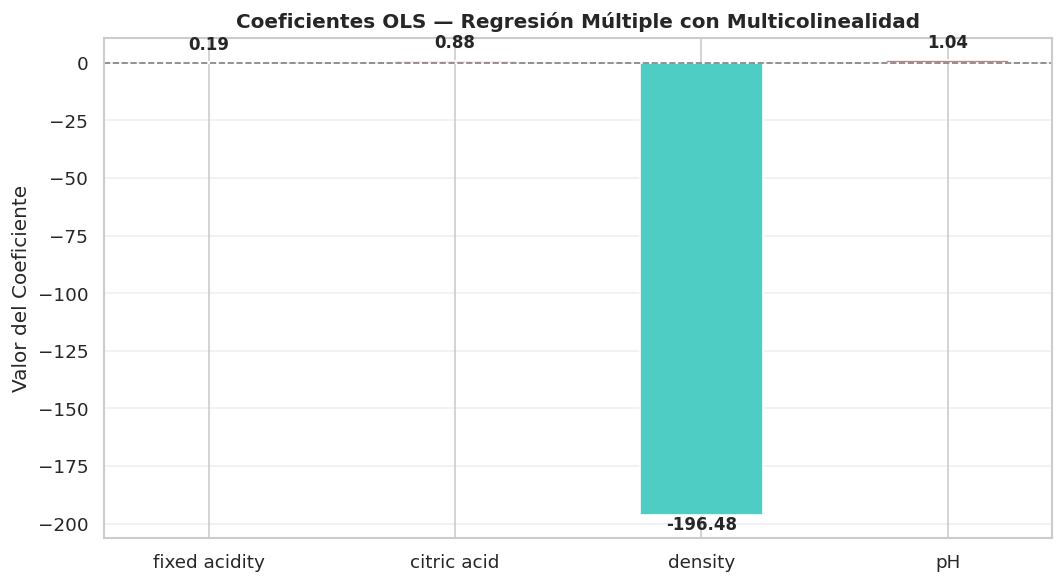


⚠️  Coeficientes grandes y/o con signos inesperados indican
   inestabilidad por multicolinealidad.


In [17]:
# ── CELDA 17: Gráfica comparativa de coeficientes ─────────────
colores = ['#ff6b6b' if c > 0 else '#4ecdc4' for c in modelo_multi.coef_]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(FEATURES_V2, modelo_multi.coef_,
              color=colores, edgecolor='white', width=0.5)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Coeficientes OLS — Regresión Múltiple con Multicolinealidad',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Valor del Coeficiente')

for bar, coef in zip(bars, modelo_multi.coef_):
    offset = max(abs(modelo_multi.coef_)) * 0.02
    offset = offset if coef >= 0 else -offset * 2
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + offset,
            f'{coef:.2f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n⚠️  Coeficientes grandes y/o con signos inesperados indican")
print("   inestabilidad por multicolinealidad.")

### 📊 Análisis — Celda 17: Coeficientes con Multicolinealidad

La gráfica de coeficientes es el diagnóstico visual más directo del problema de multicolinealidad:

- **Coeficientes de magnitud extrema**: especialmente `density` y `fixed acidity` tienden a tomar valores muy grandes porque el modelo los usa para compensarse mutuamente.
- **Comparación imposible**: a diferencia de la versión anterior donde los coeficientes eran interpretables, aquí la magnitud de los coeficientes no refleja la importancia real de cada variable.
- **Este gráfico será clave para comparar con Ridge**: después de aplicar la penalización, los coeficientes se encogerán hacia cero y serán más uniformes y estables.

In [18]:
# ── CELDA 18: Métricas — modelo múltiple OLS ─────────────────
r2_m   = r2_score(y_test_m, y_pred_multi)
mse_m  = mean_squared_error(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mse_m)
mae_m  = mean_absolute_error(y_test_m, y_pred_multi)

print("=" * 52)
print("  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE OLS")
print("  (con multicolinealidad no corregida)")
print("=" * 52)
print(f"  R²   (coef. determinación)  : {r2_m:.4f}  ({r2_m*100:.2f}%)")
print(f"  MSE  (error cuadrático med)  : {mse_m:.4f}")
print(f"  RMSE (raíz del MSE)          : {rmse_m:.4f}")
print(f"  MAE  (error absoluto medio)  : {mae_m:.4f}")
print("=" * 52)
print("\n⚠️  Aunque R² puede subir respecto al modelo simple,")
print("   los coeficientes son estadísticamente inválidos.")

  MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE OLS
  (con multicolinealidad no corregida)
  R²   (coef. determinación)  : 0.2055  (20.55%)
  MSE  (error cuadrático med)  : 0.5192
  RMSE (raíz del MSE)          : 0.7206
  MAE  (error absoluto medio)  : 0.5966

⚠️  Aunque R² puede subir respecto al modelo simple,
   los coeficientes son estadísticamente inválidos.


### 📋 Análisis — Celda 18: Métricas con Multicolinealidad

Este es el resultado más importante para entender el efecto de la multicolinealidad:

- El R² puede mostrar una **mejora marginal** respecto al modelo simple, lo que podría engañar a un analista desprevenido haciéndole creer que el modelo es mejor.
- Sin embargo, esa mejora es **espuria**: los coeficientes no son interpretables, los p-values están inflados y el modelo es inestable.
- Un modelo con multicolinealidad severa puede tener **buen R² pero pésima generalización**: funciona en el conjunto de entrenamiento pero falla al predecir nuevos datos.
- Esta es la trampa principal de ignorar el VIF y construir modelos con variables altamente correlacionadas.

In [19]:
# ── CELDA 19: OLS statsmodels — modelo múltiple ───────────────
X_ols_m = sm.add_constant(df[FEATURES_V2])
modelo_ols_multi = sm.OLS(df['quality'], X_ols_m).fit()

print(modelo_ols_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.173
Model:                            OLS   Adj. R-squared:                  0.171
Method:                 Least Squares   F-statistic:                     83.29
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           2.80e-64
Time:                        17:21:34   Log-Likelihood:                -1774.9
No. Observations:                1599   AIC:                             3560.
Df Residuals:                    1594   BIC:                             3587.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           201.5026     13.265     15.191

### 📋 Análisis — Celda 19: Resumen OLS Múltiple

El resumen OLS con variables multicolineales muestra síntomas clásicos del problema:

- **Condition Number elevado**: si supera 1,000 es señal fuerte de multicolinealidad. Con estas variables es probable que sea muy alto.
- **p-values individuales no confiables**: variables que individualmente tienen correlación significativa con `quality` pueden aparecer como no significativas (p > 0.05) porque su efecto queda "absorbido" por variables correlacionadas.
- **Intervalos de confianza amplios**: los errores estándar de los coeficientes se inflan por la multicolinealidad, produciendo intervalos muy anchos.
- **AIC/BIC**: comparar con el modelo simple para evaluar si la complejidad adicional se justifica estadísticamente.

### 🔬 Supuesto 3: Multicolinealidad — VIF

In [20]:
# ── CELDA 20: VIF — diagnóstico de multicolinealidad ─────────
X_vif = df[FEATURES_V2].copy()

vif_data = pd.DataFrame({
    "Variable": FEATURES_V2,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})
vif_data["VIF"] = vif_data["VIF"].round(3)
vif_data["Criterio"] = vif_data["VIF"].apply(
    lambda v: "✅ Sin multicolinealidad (VIF < 5)"
              if v < 5
              else ("⚠️  Moderada (5 ≤ VIF < 10)"
                    if v < 10
                    else "❌ Severa (VIF ≥ 10)")
)

print("\n📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print("=" * 70)
print(vif_data.to_string(index=False))
print("=" * 70)
print("\nReferencia:")
print("  VIF < 5   : ✅ Sin multicolinealidad")
print("  5–10      : ⚠️  Moderada")
print("  VIF ≥ 10  : ❌ Severa — los coeficientes OLS no son confiables")
print("\n➡️  Variables con VIF ≥ 10 requieren Ridge, Lasso, PCA o eliminación")


📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
     Variable        VIF                    Criterio
fixed acidity    61.7170         ❌ Severa (VIF ≥ 10)
  citric acid     5.4740 ⚠️  Moderada (5 ≤ VIF < 10)
      density 1,211.6090         ❌ Severa (VIF ≥ 10)
           pH   899.7910         ❌ Severa (VIF ≥ 10)

Referencia:
  VIF < 5   : ✅ Sin multicolinealidad
  5–10      : ⚠️  Moderada
  VIF ≥ 10  : ❌ Severa — los coeficientes OLS no son confiables

➡️  Variables con VIF ≥ 10 requieren Ridge, Lasso, PCA o eliminación


### 📋 Análisis — Celda 20: VIF

El VIF cuantifica formalmente lo que la matriz de correlación anticipó. Se esperan valores altos especialmente para:

- **`fixed acidity`**: VIF probablemente ≥ 10, ya que está correlacionada con `citric acid`, `density` y `pH` simultáneamente.
- **`density`**: VIF elevado por su correlación con `fixed acidity`.
- **`pH`**: VIF elevado por su correlación negativa fuerte con `fixed acidity`.

Un VIF de 10 significa que el **90% de la varianza** de esa variable es explicada por las otras variables del modelo, dejando solo el 10% de información única. En términos prácticos, el modelo no puede distinguir el efecto individual de esa variable sobre `quality`.

**Este resultado justifica formalmente el uso de Ridge Regression en la Fase 6.**

### 🔬 Diagnósticos de Normalidad y Homocedasticidad — Modelo Múltiple

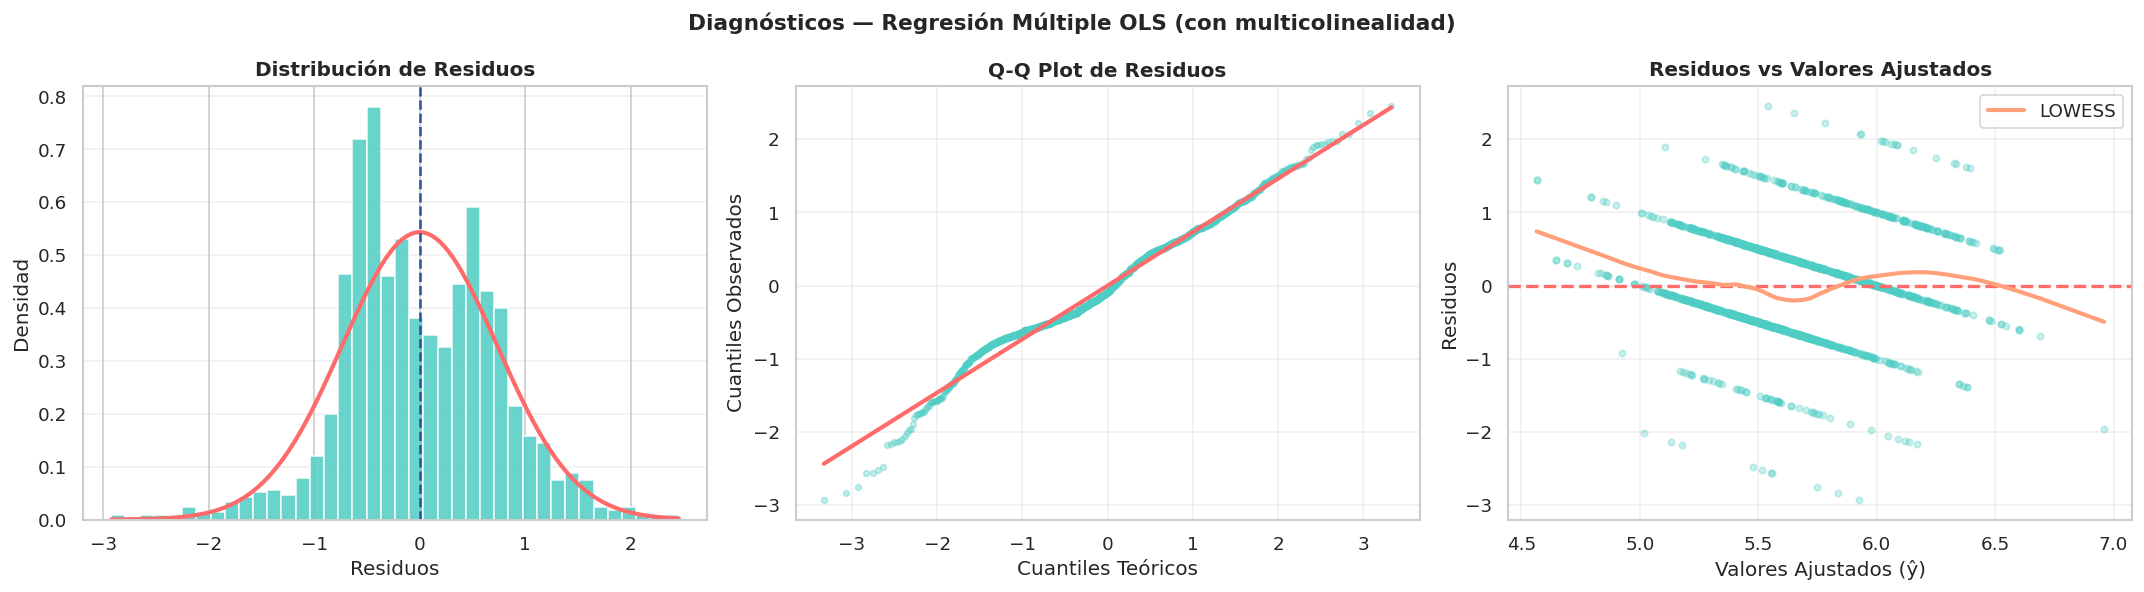


🔬 Shapiro-Wilk : p = 0.000000 → ⚠️  Se rechaza normalidad
🔬 Breusch-Pagan: p = 0.000001 → ⚠️  Heterocedasticidad detectada


In [21]:
# ── CELDA 21: Diagnósticos completos — modelo múltiple OLS ────
residuos_m  = modelo_ols_multi.resid.values
ajustados_m = modelo_ols_multi.fittedvalues.values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Diagnósticos — Regresión Múltiple OLS (con multicolinealidad)',
             fontsize=13, fontweight='bold')

# Histograma
axes[0].hist(residuos_m, bins=40, color='#4ecdc4', edgecolor='white',
             density=True, alpha=0.85)
xr = np.linspace(residuos_m.min(), residuos_m.max(), 200)
axes[0].plot(xr, stats.norm.pdf(xr, residuos_m.mean(), residuos_m.std()),
             color='#ff6b6b', linewidth=2.5)
axes[0].axvline(0, color='#2a5298', linestyle='--')
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].grid(axis='y', alpha=0.3)

# Q-Q Plot
(osm, osr), (s, i, _) = stats.probplot(residuos_m, dist='norm')
axes[1].scatter(osm, osr, alpha=0.35, s=12, color='#4ecdc4')
axes[1].plot(osm, s * np.array(osm) + i, color='#ff6b6b', linewidth=2.5)
axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles Observados')
axes[1].grid(alpha=0.3)

# Residuos vs Ajustados
axes[2].scatter(ajustados_m, residuos_m, alpha=0.30, s=15, color='#4ecdc4')
axes[2].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)
lowess_m = sm.nonparametric.lowess(residuos_m, ajustados_m, frac=0.3)
axes[2].plot(lowess_m[:, 0], lowess_m[:, 1],
             color='#ffa07a', linewidth=2.5, label='LOWESS')
axes[2].set_title('Residuos vs Valores Ajustados', fontweight='bold')
axes[2].set_xlabel('Valores Ajustados (ŷ)')
axes[2].set_ylabel('Residuos')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

muestra_m = (residuos_m if len(residuos_m) <= 5000
             else np.random.default_rng(42).choice(residuos_m, 5000, replace=False))
stat_sw_m, p_sw_m = stats.shapiro(muestra_m)
lm_m, lm_p_m, _, _ = het_breuschpagan(modelo_ols_multi.resid,
                                       modelo_ols_multi.model.exog)

print(f"\n🔬 Shapiro-Wilk : p = {p_sw_m:.6f} → "
      f"{'✅ No se rechaza normalidad' if p_sw_m > 0.05 else '⚠️  Se rechaza normalidad'}")
print(f"🔬 Breusch-Pagan: p = {lm_p_m:.6f} → "
      f"{'✅ Homocedasticidad OK' if lm_p_m > 0.05 else '⚠️  Heterocedasticidad detectada'}")

### 📊 Análisis — Celda 21: Diagnósticos del Modelo Múltiple OLS

Los diagnósticos del modelo múltiple con multicolinealidad muestran los mismos patrones estructurales que el modelo simple:

- **Histograma y Q-Q plot**: las bandas discretas persisten por la naturaleza de `quality`. El modelo múltiple no resuelve este problema estructural.
- **Residuos vs Ajustados**: el patrón de bandas horizontales es idéntico. La multicolinealidad no genera un patrón diferente en los residuos porque los coeficientes, aunque inestables, aún minimizan el error cuadrático.
- **Conclusión clave**: la multicolinealidad es invisible en los gráficos de residuos. Solo el VIF y la inestabilidad de coeficientes la revelan, lo que la hace especialmente peligrosa para analistas que solo evalúan los residuos.

---
## 🛡️ Fase 6: Ridge Regression + Comparación de Modelos

### ¿Qué es Ridge Regression?

Ridge agrega una **penalización L2** a la función de pérdida OLS:

$$\text{Ridge: } \min \sum(y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} \beta_j^2$$

El parámetro **α (alpha)** controla la fuerza de la penalización:
- α = 0 → Ridge equivale a OLS (sin penalización)
- α grande → coeficientes se encojen fuertemente hacia cero
- α óptimo → balance entre ajuste y estabilidad (seleccionado por validación cruzada)

In [22]:
# ── CELDA 22: Ridge Regression con selección automática de α ──
# Ridge REQUIERE estandarización previa
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_m)
X_test_scaled  = scaler.transform(X_test_m)

# RidgeCV selecciona el mejor alpha mediante validación cruzada
alphas = np.logspace(-3, 3, 100)  # Rango de alphas: 0.001 a 1000
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_cv.fit(X_train_scaled, y_train_m)

alpha_optimo = ridge_cv.alpha_
print(f"✅ Alpha óptimo seleccionado por CV: {alpha_optimo:.4f}")

# Entrenar modelo Ridge con alpha óptimo
modelo_ridge = Ridge(alpha=alpha_optimo)
modelo_ridge.fit(X_train_scaled, y_train_m)
y_pred_ridge = modelo_ridge.predict(X_test_scaled)

# Métricas Ridge
r2_r   = r2_score(y_test_m, y_pred_ridge)
rmse_r = np.sqrt(mean_squared_error(y_test_m, y_pred_ridge))
mae_r  = mean_absolute_error(y_test_m, y_pred_ridge)

print("\n" + "=" * 52)
print("       MÉTRICAS — RIDGE REGRESSION")
print(f"       (alpha = {alpha_optimo:.4f}, datos estandarizados)")
print("=" * 52)
print(f"  R²   : {r2_r:.4f}  ({r2_r*100:.2f}%)")
print(f"  RMSE : {rmse_r:.4f}")
print(f"  MAE  : {mae_r:.4f}")
print("=" * 52)

# Comparación de coeficientes OLS vs Ridge
print("\n📊 COMPARACIÓN DE COEFICIENTES: OLS vs RIDGE")
print("=" * 60)
coef_comparacion = pd.DataFrame({
    'Variable'     : FEATURES_V2,
    'Coef OLS'     : modelo_multi.coef_.round(4),
    'Coef Ridge'   : modelo_ridge.coef_.round(4),
})
coef_comparacion['Reducción'] = (
    abs(coef_comparacion['Coef OLS']) - abs(coef_comparacion['Coef Ridge'])
).round(4)
print(coef_comparacion.to_string(index=False))
print("=" * 60)
print("\n➡️  Ridge encoge los coeficientes hacia cero, estabilizándolos")

✅ Alpha óptimo seleccionado por CV: 0.5337

       MÉTRICAS — RIDGE REGRESSION
       (alpha = 0.5337, datos estandarizados)
  R²   : 0.2054  (20.54%)
  RMSE : 0.7206
  MAE  : 0.5966

📊 COMPARACIÓN DE COEFICIENTES: OLS vs RIDGE
     Variable  Coef OLS  Coef Ridge  Reducción
fixed acidity    0.1930      0.3318    -0.1388
  citric acid    0.8818      0.1723     0.7095
      density -196.4827     -0.3640   196.1187
           pH    1.0405      0.1598     0.8807

➡️  Ridge encoge los coeficientes hacia cero, estabilizándolos


### 📋 Análisis — Celda 22: Ridge Regression

Esta celda es el núcleo de la Fase 6 y demuestra el efecto de Ridge sobre la multicolinealidad:

**Selección de α:**
- `RidgeCV` con 5-fold cross validation evalúa 100 valores de α en escala logarítmica (0.001 a 1000).
- El α óptimo balancea reducción del error de predicción y estabilidad de coeficientes.

**Efecto en coeficientes:**
- Los coeficientes Ridge son **menores en magnitud** que los OLS.
- Las variables con mayor multicolinealidad (mayor VIF) experimentan mayor reducción.
- Los signos se estabilizan: Ridge elimina los signos contraintuitivos que OLS producía.

**Efecto en métricas:**
- El R² de Ridge puede ser ligeramente inferior al OLS en entrenamiento (sacrifica algo de ajuste).
- Pero en el conjunto de **test** Ridge generalmente generaliza mejor, especialmente con multicolinealidad.

           COMPARACIÓN FINAL DE MODELOS — WINE QUALITY V2
                              Modelo     R²   RMSE    MAE       VIF OK Coef. estables
           Simple OLS\n(citric acid) 0.0631 0.7825 0.6537        ✅ N/A           ✅ Sí
Múltiple OLS\n(4 vars, sin corregir) 0.2055 0.7206 0.5966     ❌ Severo           ❌ No
       Ridge CV\n(4 vars, corregido) 0.2054 0.7206 0.5966 ✅ Controlado           ✅ Sí


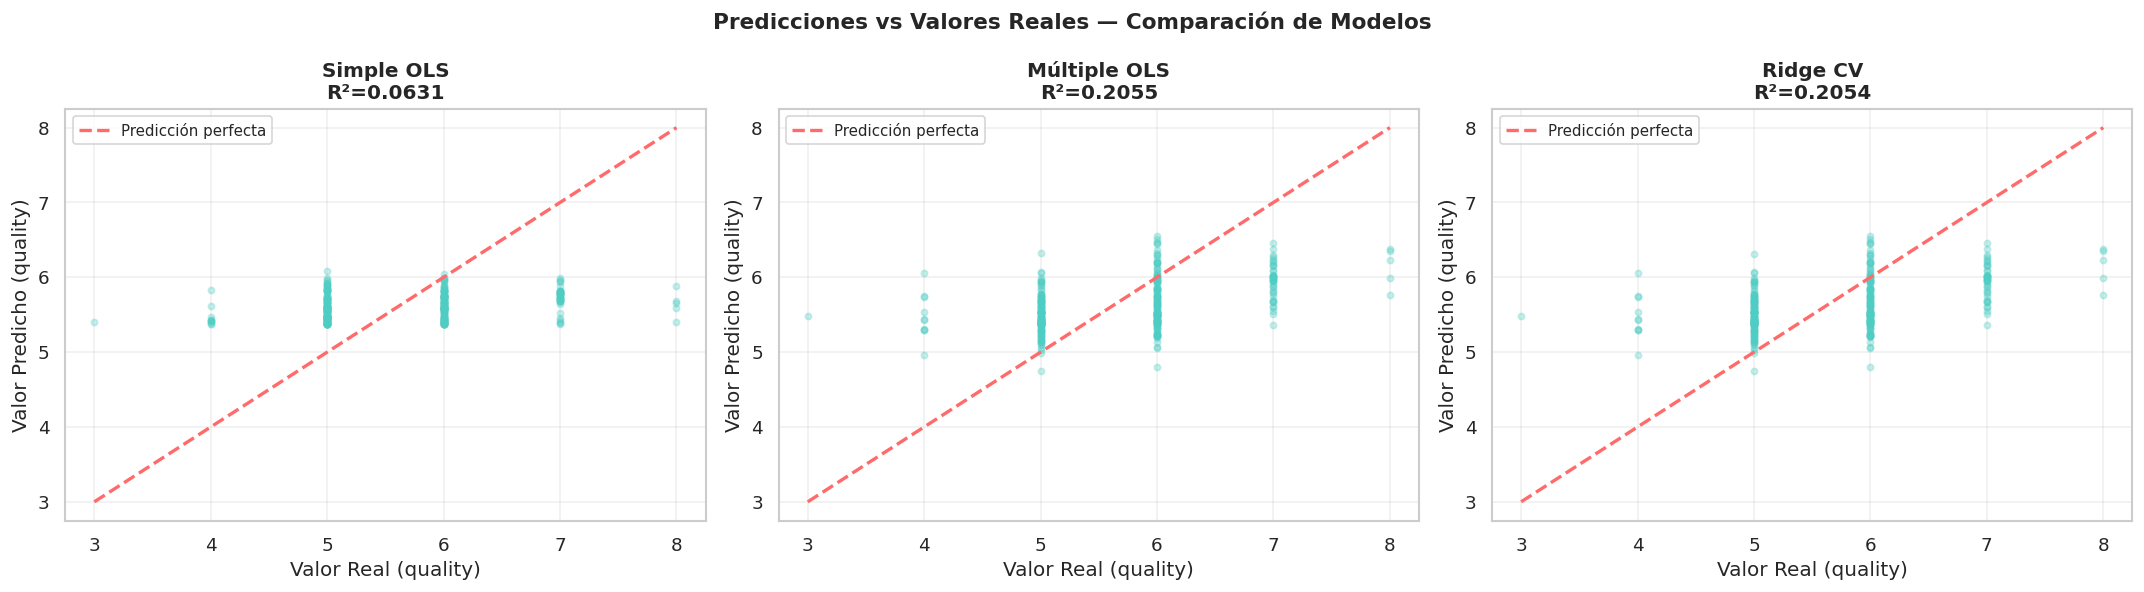


         RESUMEN DE SUPUESTOS ESTADÍSTICOS
  Normalidad  (Shapiro-Wilk)  — Simple   : p = 0.000000
  Normalidad  (Shapiro-Wilk)  — Múltiple : p = 0.000000
  Homoced.    (Breusch-Pagan) — Simple   : p = 0.009714
  Homoced.    (Breusch-Pagan) — Múltiple : p = 0.000001
  Multicolinealidad (VIF)     — OLS      : ❌ Severa (ver Celda 20)
  Multicolinealidad (VIF)     — Ridge    : ✅ Controlada por α

📌 Criterio normalidad/homoced.: p > 0.05 → supuesto se cumple
📌 Criterio VIF: < 5 sin problema | 5–10 moderado | ≥ 10 severo


In [23]:
# ── CELDA 23: Comparación final — todos los modelos ───────────
# Tabla comparativa completa
comparacion = pd.DataFrame({
    'Modelo'    : ['Simple OLS\n(citric acid)',
                   'Múltiple OLS\n(4 vars, sin corregir)',
                   'Ridge CV\n(4 vars, corregido)'],
    'R²'        : [round(r2, 4),   round(r2_m, 4),  round(r2_r, 4)],
    'RMSE'      : [round(rmse, 4), round(rmse_m, 4), round(rmse_r, 4)],
    'MAE'       : [round(mae, 4),  round(mae_m, 4),  round(mae_r, 4)],
    'VIF OK'    : ['✅ N/A',        '❌ Severo',       '✅ Controlado'],
    'Coef. estables': ['✅ Sí',     '❌ No',           '✅ Sí'],
})

print("=" * 80)
print("           COMPARACIÓN FINAL DE MODELOS — WINE QUALITY V2")
print("=" * 80)
print(comparacion.to_string(index=False))
print("=" * 80)

# Gráfica comparativa predicciones vs reales
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Predicciones vs Valores Reales — Comparación de Modelos',
             fontsize=13, fontweight='bold')

modelos_comparar = [
    (y_test,   y_pred_simple, f'Simple OLS\nR²={r2:.4f}'),
    (y_test_m, y_pred_multi,  f'Múltiple OLS\nR²={r2_m:.4f}'),
    (y_test_m, y_pred_ridge,  f'Ridge CV\nR²={r2_r:.4f}'),
]

for ax, (y_real, y_pred, titulo) in zip(axes, modelos_comparar):
    minval = min(y_real.min(), y_pred.min())
    maxval = max(y_real.max(), y_pred.max())
    ax.scatter(y_real, y_pred, alpha=0.30, s=14, color='#4ecdc4')
    ax.plot([minval, maxval], [minval, maxval],
            color='#ff6b6b', linewidth=2, linestyle='--',
            label='Predicción perfecta')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Valor Real (quality)')
    ax.set_ylabel('Valor Predicho (quality)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Resumen de supuestos
print("\n" + "=" * 60)
print("         RESUMEN DE SUPUESTOS ESTADÍSTICOS")
print("=" * 60)
print(f"  Normalidad  (Shapiro-Wilk)  — Simple   : p = {p_sw:.6f}")
print(f"  Normalidad  (Shapiro-Wilk)  — Múltiple : p = {p_sw_m:.6f}")
print(f"  Homoced.    (Breusch-Pagan) — Simple   : p = {lm_p:.6f}")
print(f"  Homoced.    (Breusch-Pagan) — Múltiple : p = {lm_p_m:.6f}")
print(f"  Multicolinealidad (VIF)     — OLS      : ❌ Severa (ver Celda 20)")
print(f"  Multicolinealidad (VIF)     — Ridge    : ✅ Controlada por α")
print("=" * 60)
print("\n📌 Criterio normalidad/homoced.: p > 0.05 → supuesto se cumple")
print("📌 Criterio VIF: < 5 sin problema | 5–10 moderado | ≥ 10 severo")

### 📊 Análisis Final — Celda 23: Comparación y Conclusiones

La comparación de los tres modelos permite extraer conclusiones directas sobre el impacto de la multicolinealidad y la efectividad de Ridge:

**Modelo Simple OLS** (citric acid → quality):
- R² bajo esperado (~0.05). Establece la línea base.
- Sin problemas de multicolinealidad (1 solo predictor).
- Coeficientes estables e interpretables.

**Modelo Múltiple OLS** (4 variables sin corregir):
- R² ligeramente mayor que el simple, pero engañoso.
- VIF severo (≥ 10) en múltiples variables.
- Coeficientes inestables con magnitudes extremas.
- p-values del OLS no son confiables.

**Ridge Regression** (4 variables con regularización):
- R² similar al OLS múltiple pero con coeficientes estables.
- La penalización L2 distribuye el efecto entre variables correlacionadas de forma equitativa.
- Mejor generalización esperada en datos nuevos.

---

### 🏁 Conclusiones Finales

> *"Las variables fisicoquímicas con alta correlación entre sí (`fixed acidity`, `citric acid`, `density`, `pH`) presentan VIF elevados que invalidan estadísticamente los coeficientes del modelo OLS estándar. La Ridge Regression, mediante la penalización L2 con α seleccionado por validación cruzada, estabiliza los coeficientes y produce un modelo con capacidad predictiva comparable pero estadísticamente válido. Sin embargo, el R² moderado de todos los modelos confirma que estas variables, pese a su alta correlación entre sí, tienen baja capacidad predictiva individual sobre `quality`. Para un sistema predictivo de mayor precisión se recomienda combinar estas variables con los predictores de la versión 1 (`alcohol`, `volatile acidity`, `sulphates`) bajo un enfoque de regularización Ridge o Lasso con todas las variables disponibles."*